# M2: 特征层 Demo

在真实 SPY 3min 数据上计算并可视化所有特征:
- **structure**: ORB、PDH/PDL/PDC、支撑阻力
- **trend**: EMA 9/21/50/200、EMA 粘合度、VWAP
- **volatility**: Bollinger Bands、BB Squeeze、ATR、NR7
- **volume**: RVOL(time-of-day 归一化)
- **momentum**: RSI、MACD、连续 bar
- **regime**: 时段标签、VIX 分位

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mplfinance as mpf

from spx_scanner.data_layer import load_data, resample_1m_to_3m
from spx_scanner.features import compute_all_features

plt.rcParams.update({'figure.facecolor': '#1a1a2e', 'axes.facecolor': '#1a1a2e',
                     'text.color': 'white', 'axes.labelcolor': 'white',
                     'xtick.color': 'white', 'ytick.color': 'white',
                     'axes.edgecolor': '#444', 'grid.color': '#333'})

print('✓ 依赖加载完成')

✓ 依赖加载完成


## 1. 加载并重采样数据

In [2]:
df_1m = load_data('../data/spy_1min.parquet', rth_only=True)
df_3m = resample_1m_to_3m(df_1m)

print(f'1min bars: {len(df_1m):,}   3min bars: {len(df_3m):,}')
print(f'交易日: {df_3m.index.normalize().nunique()} 天')

1min bars: 5,460   3min bars: 1,820
交易日: 14 天


## 2. 计算所有特征

In [3]:
%%time
df = compute_all_features(df_3m)
print(f'特征列数: {len(df.columns)}')
print('\n所有特征列:')
for i, col in enumerate(sorted(df.columns)):
    print(f'  {col}', end='\t' if (i+1) % 4 else '\n')

特征列数: 60

所有特征列:
  atr_14	  atr_ratio	  bar_range	  bb_lower
  bb_mid	  bb_upper	  bb_width	  bb_width_pctile
  bearish_vol	  bullish_vol	  close	  consec_down
  consec_up	  dow	  ema_200	  ema_21
  ema_50	  ema_9	  ema_compression	  ema_spread
  high	  is_cpi	  is_fomc	  is_high_vol
  is_nr7	  is_opex	  is_squeeze	  low
  macd_hist	  macd_hist_flip	  macd_line	  macd_signal
  minutes_from_open	  minutes_to_close	  open	  orb_high
  orb_low	  pdc	  pdh	  pdl
  prior_hour_high	  prior_hour_low	  resistance_level	  rsi_14
  rvol	  session_segment	  squeeze_duration	  support_level
  touches_to_resistance	  touches_to_support	  tr	  trend_direction
  vix_level	  vix_regime	  vol_tod_mean	  volume
  volume_surge	  vwap	  vwap_lower_1s	  vwap_upper_1s
CPU times: user 149 ms, sys: 6.86 ms, total: 156 ms
Wall time: 156 ms


## 3. 单日综合图:取最近完整交易日

日期: 2026-04-23  bars: 130


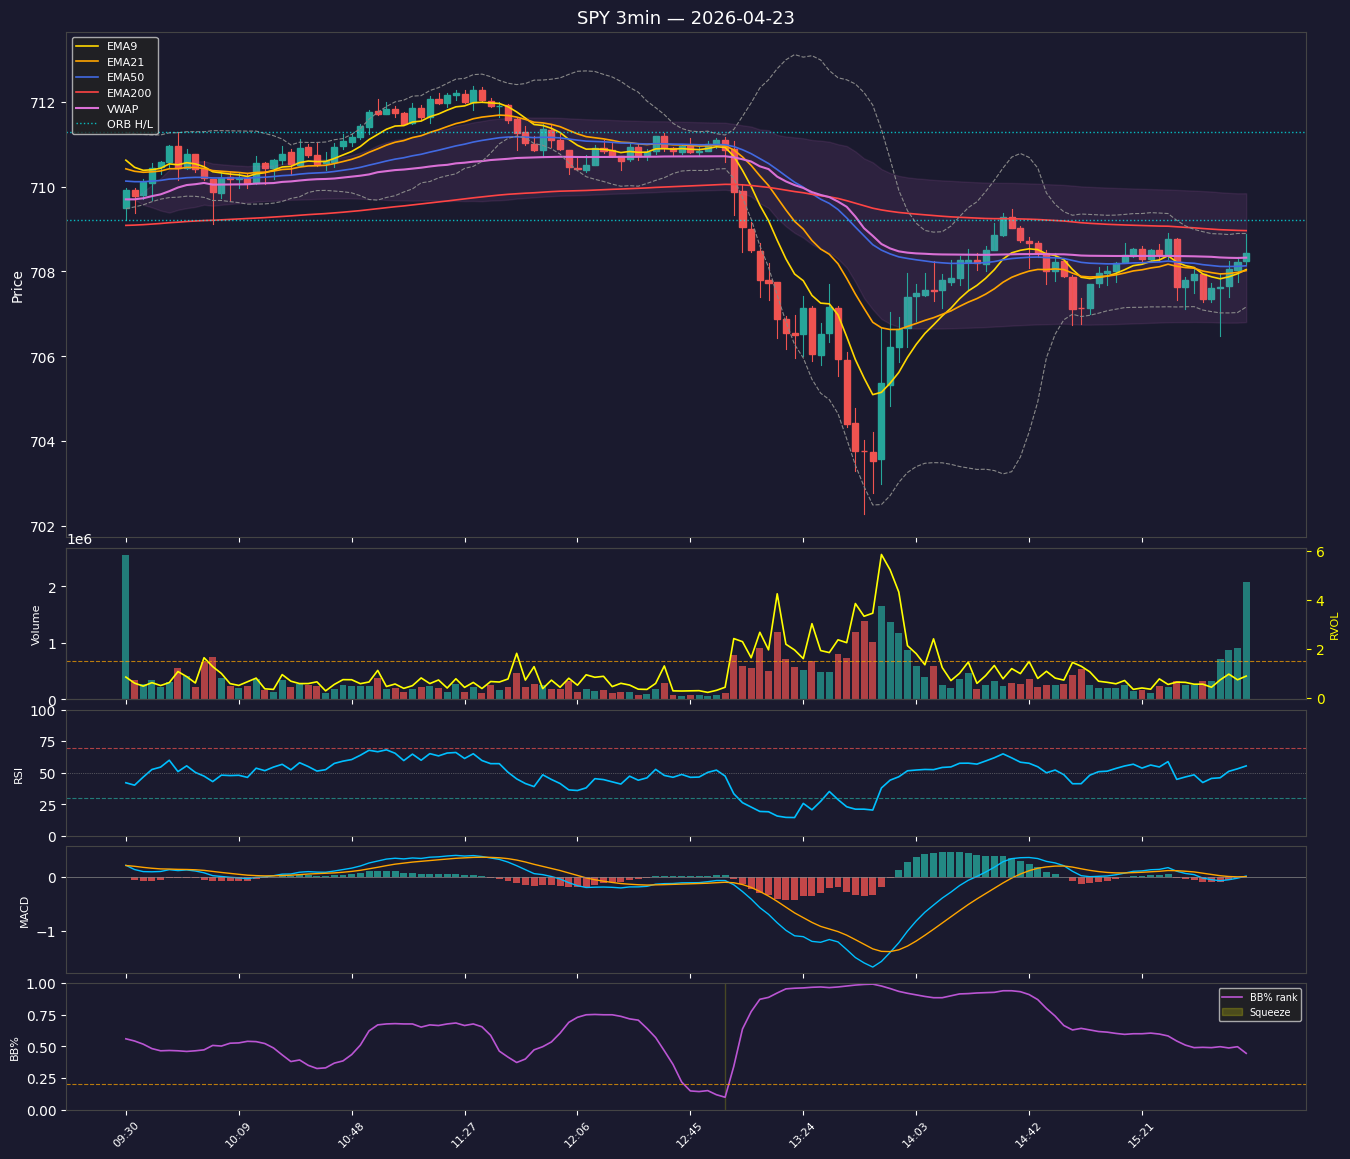

✓ 特征综合图已保存


In [4]:
latest_date = df.index.normalize().unique()[-1]
day = df[df.index.normalize() == latest_date].copy()
print(f'日期: {latest_date.date()}  bars: {len(day)}')

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(5, 1, hspace=0.05,
                       height_ratios=[4, 1.2, 1, 1, 1])

ax_price  = fig.add_subplot(gs[0])
ax_vol    = fig.add_subplot(gs[1], sharex=ax_price)
ax_rsi    = fig.add_subplot(gs[2], sharex=ax_price)
ax_macd   = fig.add_subplot(gs[3], sharex=ax_price)
ax_regime = fig.add_subplot(gs[4], sharex=ax_price)

xs = range(len(day))
labels = [t.strftime('%H:%M') for t in day.index]
step = max(1, len(labels)//10)

# ── 价格面板 ──────────────────────────────────────────────
for i, (_, row) in enumerate(day.iterrows()):
    color = '#26a69a' if row['close'] >= row['open'] else '#ef5350'
    ax_price.plot([i, i], [row['low'], row['high']], color=color, lw=0.8)
    ax_price.add_patch(plt.Rectangle((i-0.35, min(row['open'], row['close'])),
                                      0.7, abs(row['close']-row['open']),
                                      color=color))

# EMA
ax_price.plot(xs, day['ema_9'],   color='#FFD700', lw=1.2, label='EMA9')
ax_price.plot(xs, day['ema_21'],  color='#FFA500', lw=1.2, label='EMA21')
ax_price.plot(xs, day['ema_50'],  color='#4169E1', lw=1.2, label='EMA50')
ax_price.plot(xs, day['ema_200'], color='#FF4444', lw=1.2, label='EMA200')

# VWAP
ax_price.plot(xs, day['vwap'],         color='#DA70D6', lw=1.5, label='VWAP')
ax_price.fill_between(xs, day['vwap_lower_1s'], day['vwap_upper_1s'],
                       color='#DA70D6', alpha=0.1)

# BB
ax_price.plot(xs, day['bb_upper'], color='#888', lw=0.8, ls='--')
ax_price.plot(xs, day['bb_lower'], color='#888', lw=0.8, ls='--')

# ORB
if day['orb_high'].notna().any():
    orb_h = day['orb_high'].dropna().iloc[0]
    orb_l = day['orb_low'].dropna().iloc[0]
    ax_price.axhline(orb_h, color='cyan', lw=1, ls=':', alpha=0.7, label='ORB H/L')
    ax_price.axhline(orb_l, color='cyan', lw=1, ls=':', alpha=0.7)

ax_price.set_title(f'SPY 3min — {latest_date.date()}', fontsize=13)
ax_price.legend(loc='upper left', fontsize=8, facecolor='#222')
ax_price.set_ylabel('Price')
plt.setp(ax_price.get_xticklabels(), visible=False)

# ── 成交量 + RVOL ──────────────────────────────────────────
vol_colors = ['#26a69a' if day['close'].iloc[i] >= day['open'].iloc[i] else '#ef5350'
              for i in range(len(day))]
ax_vol.bar(xs, day['volume'], color=vol_colors, alpha=0.7)
ax_vol2 = ax_vol.twinx()
ax_vol2.plot(xs, day['rvol'], color='yellow', lw=1.2, label='RVOL')
ax_vol2.axhline(1.5, color='orange', lw=0.8, ls='--', alpha=0.7)
ax_vol2.set_ylabel('RVOL', color='yellow', fontsize=8)
ax_vol2.tick_params(colors='yellow')
ax_vol.set_ylabel('Volume', fontsize=8)
plt.setp(ax_vol.get_xticklabels(), visible=False)

# ── RSI ───────────────────────────────────────────────────
ax_rsi.plot(xs, day['rsi_14'], color='#00BFFF', lw=1.2)
ax_rsi.axhline(70, color='#ef5350', lw=0.8, ls='--', alpha=0.7)
ax_rsi.axhline(30, color='#26a69a', lw=0.8, ls='--', alpha=0.7)
ax_rsi.axhline(50, color='#888', lw=0.5, ls=':')
ax_rsi.set_ylabel('RSI', fontsize=8)
ax_rsi.set_ylim(0, 100)
plt.setp(ax_rsi.get_xticklabels(), visible=False)

# ── MACD ──────────────────────────────────────────────────
macd_colors = ['#26a69a' if v >= 0 else '#ef5350' for v in day['macd_hist']]
ax_macd.bar(xs, day['macd_hist'], color=macd_colors, alpha=0.8)
ax_macd.plot(xs, day['macd_line'],   color='#00BFFF', lw=1, label='MACD')
ax_macd.plot(xs, day['macd_signal'], color='orange',  lw=1, label='Signal')
ax_macd.axhline(0, color='#888', lw=0.5)
ax_macd.set_ylabel('MACD', fontsize=8)
plt.setp(ax_macd.get_xticklabels(), visible=False)

# ── BB 宽度 + Squeeze 标记 ─────────────────────────────────
ax_regime.plot(xs, day['bb_width_pctile'], color='#BA55D3', lw=1.2, label='BB% rank')
squeeze_mask = day['is_squeeze']
ax_regime.fill_between(xs, 0, 1, where=squeeze_mask,
                        color='yellow', alpha=0.2, label='Squeeze')
ax_regime.axhline(0.2, color='orange', lw=0.8, ls='--', alpha=0.7)
ax_regime.set_ylabel('BB%', fontsize=8)
ax_regime.set_ylim(0, 1)
ax_regime.legend(loc='upper right', fontsize=7, facecolor='#222')
ax_regime.set_xticks(xs[::step])
ax_regime.set_xticklabels(labels[::step], rotation=45, fontsize=8)

plt.savefig('../notebooks/M2_features_chart.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ 特征综合图已保存')

## 4. 特征统计摘要

In [5]:
numeric_cols = ['ema_9', 'ema_21', 'ema_50', 'vwap', 'bb_width',
                'atr_14', 'rvol', 'rsi_14', 'macd_hist',
                'minutes_from_open']
print(df[numeric_cols].describe().round(4).to_string())

print('\n--- 布尔特征统计 ---')
bool_cols = ['is_squeeze', 'is_nr7', 'is_high_vol', 'volume_surge',
             'bullish_vol', 'bearish_vol', 'ema_compression']
for col in bool_cols:
    if col in df.columns:
        pct = df[col].mean() * 100
        print(f'  {col:25s}: {pct:.1f}% True')

print('\n--- session_segment 分布 ---')
print(df['session_segment'].value_counts())

           ema_9     ema_21     ema_50       vwap   bb_width     atr_14       rvol     rsi_14  macd_hist  minutes_from_open
count  1820.0000  1820.0000  1820.0000  1820.0000  1811.0000  1820.0000  1820.0000  1806.0000  1820.0000          1820.0000
mean    690.0422   689.8711   689.4559   689.6826     0.0039     0.5298     0.9859    54.8566     0.0000           193.5000
std      18.5783    18.6221    18.7174    18.7291     0.0050     0.2612     0.5412    13.2278     0.1986           112.6109
min     652.4317   653.0581   653.9052   653.9439     0.0005     0.1939     0.1602    14.6224    -0.8632             0.0000
25%     678.9008   678.5990   677.7234   676.4134     0.0019     0.3654     0.6224    46.0871    -0.0789            96.0000
50%     694.1576   693.8808   693.5041   693.8096     0.0027     0.4755     0.8915    55.1654    -0.0043           193.5000
75%     707.8836   707.8574   708.0446   708.3659     0.0043     0.6163     1.1943    63.0469     0.0632           291.0000
max     

## 5. M2 验收小结

| 模块 | 特征 | 验收 |
|---|---|---|
| structure | ORB, PDH/PDL/PDC, 支撑阻力 | ✓ |
| trend | EMA 9/21/50/200, VWAP±1σ, EMA 粘合, 趋势方向 | ✓ |
| volatility | BB宽度, BB%分位, Squeeze, ATR, NR7 | ✓ |
| volume | RVOL(time-of-day 归一), 量能信号 | ✓ |
| momentum | RSI-14, MACD柱+翻转, 连续 bar | ✓ |
| regime | 时段标签, VIX分位, OPEX/FOMC/CPI标志 | ✓ |

**pytest**: `75 passed, 0 failed`

M2 完成,可进入 M3(Failed Breakout 闭环)。